# Diabetes Health-Indicator Risk Prediction — Model Training Run

> **For research and educational purposes only.** The model below is trained on a
> historical public dataset. Its output is not a medical diagnosis and not medical
> advice. See the model card for what this model must **not** be used for.

This notebook **does not train anything** — it reads the artifacts produced by

```
python -m scripts.train_diabetes
```

so every number shown here is the same number in `reports/diabetes/` and
`models/diabetes/metadata.json`. Re-run that script to refresh them.


In [1]:
import sys, os
# Make the repository root importable when the kernel starts in notebooks/.
_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

import json
from pathlib import Path

import joblib
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 60)

DISEASE = "diabetes"
reports = Path("reports") / DISEASE
models = Path("models") / DISEASE

metrics = json.loads((reports / "metrics.json").read_text(encoding="utf-8"))
card = json.loads((models / "metadata.json").read_text(encoding="utf-8"))
shap_global = json.loads((reports / "shap_global.json").read_text(encoding="utf-8"))

print(card["module"])
print("algorithm :", card["model"]["algorithm"])
print("calibration:", card["model"]["calibration"])


Diabetes Health-Indicator Risk Prediction
algorithm : xgboost
calibration: isotonic


## 1. How the data was split

Preprocessing (imputation, scaling, one-hot) happens **inside** the model pipeline, so
it is fitted on training folds only and never sees the held-out rows.


In [2]:
pd.Series(metrics["split"]).to_frame("value")

,value
n_total,253680.0000
n_train,202719.0000
n_test,50961.0000
n_duplicate_rows,25772.0000
n_unique_feature_vectors,227908.0000
groups_shared_across_split,0.0000
overall_positive_rate,0.1393
train_positive_rate,0.1396
test_positive_rate,0.1383


## 2. Model comparison

Five candidate pipelines, 5-fold cross-validated on the training set.

In [3]:
pd.read_csv(reports / "model_comparison.csv")

,model,smote,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,rank_score
0,xgboost,False,0.8301,0.0014,0.4354,0.0077,0.7951,0.0037,0.3065,0.0049,0.4424,0.0053,0.6652
1,lightgbm,False,0.8288,0.0014,0.4331,0.0075,0.7887,0.0051,0.3083,0.0039,0.4433,0.0046,0.6625
2,logreg,False,0.8221,0.0012,0.4040,0.0072,0.7651,0.0025,0.3114,0.0041,0.4426,0.0044,0.6434
3,random_forest,False,0.8049,0.0023,0.3899,0.0070,0.1474,0.0030,0.5265,0.0102,0.2304,0.0044,0.5074


### Was the winner meaningfully better?

`selection_margin` compares the tuned top-2 against the fold-to-fold standard deviation.
When the gap is smaller than that noise, the leaderboard is **not** a quality ranking.


In [4]:
pd.Series(metrics["selection_margin"]).to_frame("value")

,value
selected,xgboost
selected_tuned_roc_auc,0.83035
runner_up,lightgbm
runner_up_tuned_roc_auc,0.830092
gap,0.000259
cv_roc_auc_std,0.001376
decisive,False
reasons_to_doubt,[the gap (0.0003) is smaller than the selected...
gap_within_cv_noise,True


In [5]:
display(Markdown((reports / "SELECTION.md").read_text(encoding="utf-8")))

# Model selection — diabetes

Selection criteria (in order): ROC-AUC and PR-AUC (discrimination), then recall/sensitivity for the positive class, then calibration. **Not** accuracy.

## Cross-validated comparison (training set, 5-fold grouped CV)

| model | smote | roc_auc_mean | roc_auc_std | pr_auc_mean | pr_auc_std | recall_mean | recall_std | precision_mean | precision_std | f1_mean | f1_std | rank_score |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| xgboost | False | 0.8301 | 0.0014 | 0.4354 | 0.0077 | 0.7951 | 0.0037 | 0.3065 | 0.0049 | 0.4424 | 0.0053 | 0.6652 |
| lightgbm | False | 0.8288 | 0.0014 | 0.4331 | 0.0075 | 0.7887 | 0.0051 | 0.3083 | 0.0039 | 0.4433 | 0.0046 | 0.6625 |
| logreg | False | 0.8221 | 0.0012 | 0.4040 | 0.0072 | 0.7651 | 0.0025 | 0.3114 | 0.0041 | 0.4426 | 0.0044 | 0.6434 |
| random_forest | False | 0.8049 | 0.0023 | 0.3899 | 0.0070 | 0.1474 | 0.0030 | 0.5265 | 0.0102 | 0.2304 | 0.0044 | 0.5074 |

### Candidates that were not run

- **`svc`** — Computationally intractable at this scale. SVC training is super-quadratic in the number of samples, and `probability=True` adds an internal 5-fold Platt calibration on top. Measured fit times on this training set were 1.07 s at n=2,000, 4.27 s at n=4,000, 17.52 s at n=8,000 and 85.09 s at n=16,000 — an empirical exponent of ~2.28, which extrapolates to roughly 7.7 hours for a single fit on the full 202,719 training rows and ~23 hours for one 5-fold cross-validation pass, before any hyper-parameter search. Excluded on cost, not on performance: it was never scored, so nothing is claimed about how it would have done.

## Tuning (RandomizedSearchCV, scoring = ROC-AUC)

- **xgboost**: CV ROC-AUC 0.8304
  - params: `{'clf__colsample_bytree': 0.7727780074568463, 'clf__learning_rate': 0.02692655251486473, 'clf__max_depth': 4, 'clf__min_child_weight': 3, 'clf__n_estimators': 766, 'clf__reg_lambda': 8.906204386161678, 'clf__subsample': 0.786705157299192}`
- **lightgbm**: CV ROC-AUC 0.8301
  - params: `{'clf__colsample_bytree': 0.7836995567863468, 'clf__learning_rate': 0.03111201090739482, 'clf__max_depth': 6, 'clf__min_child_samples': 26, 'clf__n_estimators': 508, 'clf__num_leaves': 16, 'clf__reg_lambda': 1.4655354118727704, 'clf__subsample': 0.9754210836063001}`
- **logreg**: CV ROC-AUC 0.8221
  - params: `{'clf__C': 0.0745934328572655, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}`

## Selected: `xgboost`

`xgboost` was chosen from 4 candidate pipelines. The cross-validated ranking (0.4·ROC-AUC + 0.4·PR-AUC + 0.2·recall) put `xgboost` first before tuning. After randomised hyper-parameter search the tuned cross-validated ROC-AUC scores were: xgboost 0.8304, lightgbm 0.8301, logreg 0.8221; `xgboost` was highest and was refit on the full training set. Accuracy was recorded but was not used as a selection criterion.

### How decisive was this?

**Not decisive.** `xgboost` beat `lightgbm` by 0.0003 cross-validated ROC-AUC, but:

- the gap (0.0003) is smaller than the selected model's fold-to-fold standard deviation (0.0014).
- the gap (0.0003) is below 0.005, the practical resolution of ROC-AUC at this sample size.

Read the leaderboard as *these models perform comparably*, not as a quality ranking. A different random seed could reorder them. The choice of algorithm here should not be presented as a finding.

---
*Generated by `ml.training.experiment.run_experiment`. Every number above comes from that run.*


## 3. Calibration

The wrapper is chosen on **out-of-fold training** scores. The test-set table below is
reported for transparency only — choosing on it would make the test metrics optimistic.


In [6]:
print("selection (training out-of-fold):")
display(pd.DataFrame(metrics["calibration_selection_train_cv"]).set_index("method"))
print("\nreported only (test set) — NOT used to choose:")
display(pd.DataFrame(metrics["calibration_test_comparison"]).set_index("method"))
print("\nchosen:", card["model"]["calibration"])
print(card["model"]["calibration_rationale"])


selection (training out-of-fold):


,brier,roc_auc
method,,
raw,0.174663,0.830326
sigmoid,0.096932,0.830539
isotonic,0.096620,0.830390



reported only (test set) — NOT used to choose:


,brier,roc_auc
method,,
raw,0.173580,0.831909
sigmoid,0.096151,0.831805
isotonic,0.095927,0.831694



chosen: isotonic
Selected 'isotonic' by out-of-fold Brier score on the training set: 0.0966 vs raw 0.1747; cross-validated ROC-AUC 0.8304 vs raw 0.8303 (tolerance 0.01). The test set played no part in this choice.


## 4. Held-out test performance

In [7]:
rows = {
    "threshold 0.5": metrics["test_set_threshold_0.5"],
    "sensitivity-oriented": {k: v for k, v in metrics["test_set_alternative_threshold"].items()
                             if k != "threshold_rule"},
}
display(pd.DataFrame(rows).loc[
    ["n", "threshold", "roc_auc", "pr_auc", "recall_sensitivity", "specificity",
     "precision", "f1", "accuracy", "brier", "cm_tn", "cm_fp", "cm_fn", "cm_tp"]
])
print(metrics["test_set_alternative_threshold"]["threshold_rule"])


,threshold 0.5,sensitivity-oriented
n,50961.000000,50961.000000
threshold,0.500000,0.138828
roc_auc,0.831694,0.831694
pr_auc,0.430710,0.430710
recall_sensitivity,0.146445,0.798354
specificity,0.982921,0.708954
precision,0.579125,0.305645
f1,0.233775,0.442052
accuracy,0.867251,0.721316
brier,0.095927,0.095927


Youden's J (max sensitivity + specificity - 1) maximised on out-of-fold predictions over the TRAINING set, then applied unchanged to the test set. The test set played no part in choosing it.


### Which threshold should you read?

0.5 is a convention, not a decision rule. On a low-prevalence problem a well-calibrated
model should rarely output a probability above 0.5 — most people really do have a
below-even chance — so thresholding there gives high specificity and low recall. That
looks like a broken model and is not one.


In [8]:
note = metrics.get("diagnostics", {}).get("operating_point_note")
display(Markdown(f"> {note}" if note else "_No operating-point note recorded._"))


> Positive-class prevalence is 0.1383. At threshold 0.5 the model recovers 0.1464 of positives at 0.9829 specificity; at the sensitivity-oriented threshold 0.1388 it recovers 0.7984 at 0.7090 specificity. The +0.6519 swing in recall means **0.5 is not a meaningful operating point for this model**. A calibrated probability on a problem with 13.8% prevalence only exceeds 0.5 for the most extreme profiles, so thresholding there behaves as a high-precision screen and misses most positives. The low recall in the 0.5 row is a property of that arbitrary cut-off, not evidence that the model failed to rank patients — ROC-AUC and PR-AUC, which are threshold-free, are the metrics to compare against other models. Any real use would set the threshold from the cost of a false negative against a false alarm.

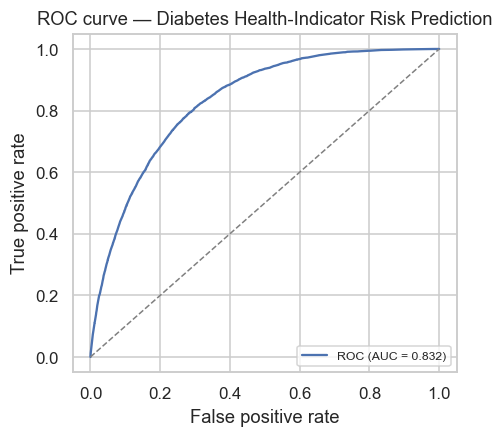

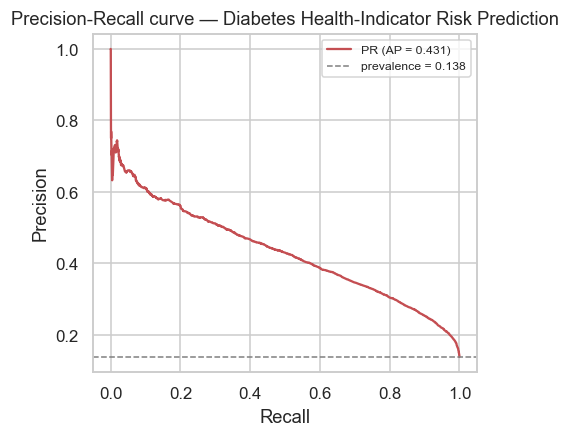

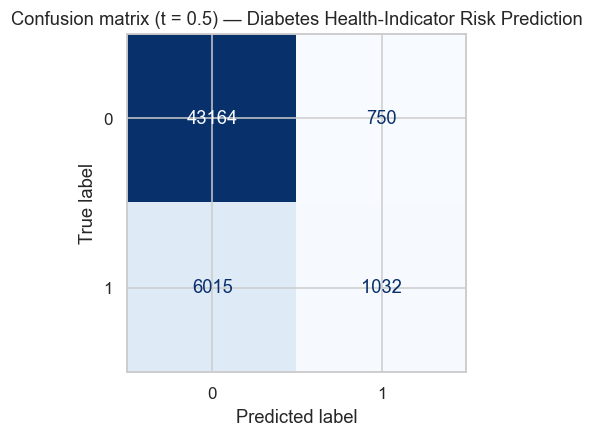

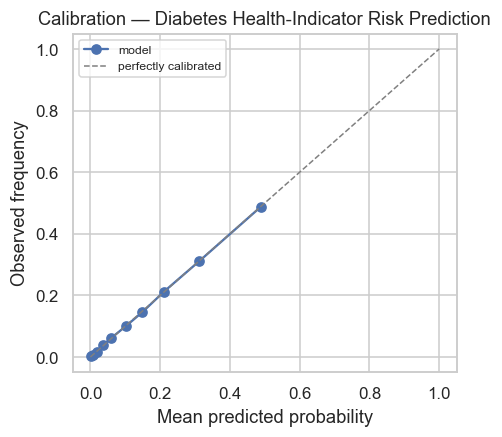

In [9]:
for name in ["roc_curve", "pr_curve", "confusion_matrix", "calibration_curve"]:
    png = reports / "figures" / f"{name}.png"
    if png.exists():
        display(Image(filename=str(png)))


### Threshold sweep

How precision, recall and specificity trade off across the decision threshold.

In [10]:
pd.read_csv(reports / "threshold_sweep.csv")

,threshold,precision,recall_sensitivity,specificity,f1,accuracy
0,0.05,0.2206,0.9485,0.4621,0.3579,0.5294
1,0.10,0.2676,0.8764,0.6150,0.4100,0.6511
2,0.15,0.3163,0.7769,0.7305,0.4496,0.7369
3,0.20,0.3597,0.6687,0.8090,0.4677,0.7896
4,0.25,0.3939,0.5834,0.8559,0.4703,0.8183
5,0.30,0.4325,0.4933,0.8961,0.4609,0.8404
6,0.35,0.4659,0.4019,0.9261,0.4315,0.8536
7,0.40,0.5065,0.3082,0.9518,0.3832,0.8628
8,0.45,0.5430,0.2202,0.9703,0.3134,0.8665
9,0.50,0.5791,0.1464,0.9829,0.2338,0.8673


## 4b. What actually drives this score?

A high ROC-AUC is not by itself evidence that the model learned clinical structure — it
can also come from how the data was collected. The probe below discards **every measured
value** and trains only on *which values are missing*. If that alone reproduces most of
the headline score, the model is largely reading which tests a clinician chose to order.

That is not train/test leakage — the split stays clean — but it is a ceiling on how far
the result transfers to a setting where these tests are ordered routinely.


In [11]:
diag = metrics.get("diagnostics", {})
print(diag.get("attribution_note", "(no diagnostics recorded)"))
print()

probe = diag.get("missingness_only_probe")
if probe:
    print("missingness-indicators-only model:")
    for k in ("n_indicator_features", "cv_roc_auc_mean", "cv_roc_auc_std",
              "test_roc_auc", "test_pr_auc", "test_accuracy"):
        if k in probe:
            print(f"  {k:<22} {probe[k]}")
    print(f"\n  full model test ROC-AUC {metrics['test_set_threshold_0.5']['roc_auc']:.4f}")
else:
    print("No missing values in this dataset — measurement pattern cannot carry signal.")

print("\ncomplete-case analysis (why it was not used instead):")
print(" ", diag.get("complete_case"))


No values are missing in this dataset, so measurement pattern cannot carry signal.

No missing values in this dataset — measurement pattern cannot carry signal.

complete-case analysis (why it was not used instead):
  {'n_total': 253680, 'n_complete_cases': 253680, 'pct_retained': 100.0, 'positive_rate_all': 0.1393, 'positive_rate_complete_cases': 0.1393}


In [12]:
miss_csv = reports / "missingness_vs_target.csv"
if miss_csv.exists():
    display(Markdown("**Is a column's missingness itself predictive of the target?**"))
    display(pd.read_csv(miss_csv))
else:
    print("No missing values to analyse.")


No missing values to analyse.


### 4c. What could any model achieve on these features?

When two rows carry an identical feature vector but different outcomes, no model that sees
only these features can get both right. That is irreducible error, and it caps accuracy
regardless of the algorithm. Reported so the gap to 1.0 is attributed honestly — and so
that it is *not* used to excuse a model sitting far below the bound.


In [13]:
dup = diag.get("duplicate_feature_vectors")
display(Markdown(f"> {diag.get('duplicate_conflict_note', '(not recorded)')}"))
if dup:
    display(pd.Series(dup).to_frame("value"))


> 38,000 of 253,680 rows (14.98%) share an identical feature vector with at least one other row, and 1,566 of those groups contain both outcome labels. 1,640 rows are therefore unwinnable for any model using only these features, capping accuracy at 0.9935 against the measured 0.8673. The bound is 0.1262 above what the model achieves, so it does NOT explain the shortfall — duplicate-label conflict is a real but minor part of the error here, and the rest is the model, the features' weak association with the outcome, or both.

,value
n_rows,253680.0000
n_unique_feature_vectors,227908.0000
n_rows_sharing_a_feature_vector,38000.0000
pct_rows_sharing_a_feature_vector,14.9800
n_duplicate_groups,12228.0000
n_conflicted_groups,1566.0000
n_rows_in_conflicted_groups,5218.0000
n_unwinnable_rows,1640.0000
max_achievable_accuracy,0.9935


### 4d. Did SMOTE actually help?

"Use SMOTE for imbalanced data" is repeated far more often than it is checked. Where this
comparison was run, the selected model was cross-validated on identical folds under SMOTE
and under class weighting. SMOTE resamples **inside** each fold's training portion only.

Watch PR-AUC rather than recall: both strategies move the operating point, so recall at a
fixed 0.5 threshold swings hard while the threshold-free ranking barely changes.


In [14]:
imb_csv = reports / "imbalance_comparison.csv"
if imb_csv.exists():
    display(Markdown(f"> {diag.get('imbalance_note', '')}"))
    display(pd.read_csv(imb_csv))
else:
    print("Imbalance strategies were not compared for this disease.")


> SMOTE vs class weighting, same model and same folds: PR-AUC 0.4243 vs 0.4354 (-0.0111, fold std 0.0082) — a degradation. ROC-AUC moved -0.0061 and recall at threshold 0.5 moved -0.5053; recall moves most because both strategies shift the operating point rather than the ranking. Shipped strategy: class_weight.

,strategy,model,fit_seconds_mean,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std
0,class_weight,xgboost,32.022621,0.830063,0.001376,0.435384,0.007692,0.795136,0.003749,0.306488,0.004862,0.442417,0.005296
1,smote,xgboost,65.882835,0.823928,0.001701,0.424258,0.008241,0.289854,0.003159,0.501157,0.009980,0.367272,0.005089


## 5. Explainability (SHAP)

SHAP values are computed on the transformed matrix and summed back onto the **original**
feature names. `additivity_max_error` is the largest gap between `base value + sum(SHAP)`
and the model's actual output — near zero means the explanation really does reconstruct
this model rather than being a plausible-looking set of numbers.


In [15]:
print("explainer:", shap_global["explainer"])
print("additivity max error:", shap_global["additivity_max_error"])
display(pd.DataFrame(shap_global["global_importance"]))


explainer: tree
additivity max error: 3.337860107421875e-06


,rank,feature,mean_abs_shap,mean_shap,description
0,1,GenHlth,0.653377,-0.275205,Self-rated general health (1 excellent - 5 poor)
1,2,HighBP,0.443666,-0.120912,Ever told by a health professional you have hi...
2,3,BMI,0.414681,-0.127471,Body Mass Index
3,4,Age,0.404216,-0.134116,13-level age category (1 = 18-24 ... 13 = 80+)
4,5,HighChol,0.298057,-0.070407,Ever told you have high cholesterol (0/1)
5,6,Income,0.139721,-0.041305,Income category (1 - 8 ordinal)
6,7,Sex,0.134759,-0.014025,"Sex (0 = female, 1 = male)"
7,8,CholCheck,0.071522,-0.028784,Cholesterol check within the past 5 years (0/1)
8,9,HeartDiseaseorAttack,0.067367,-0.020074,Coronary heart disease or myocardial infarctio...
9,10,HvyAlcoholConsump,0.065205,-0.015396,Heavy alcohol consumption (0/1)


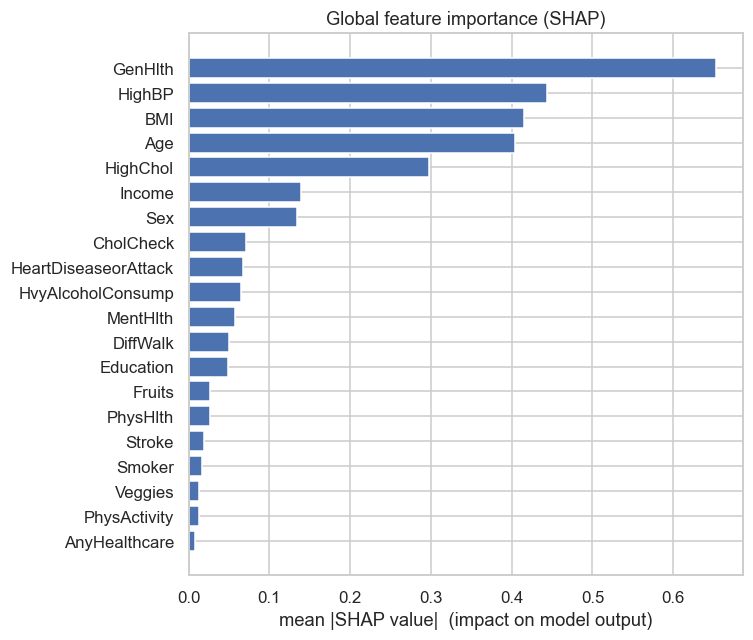

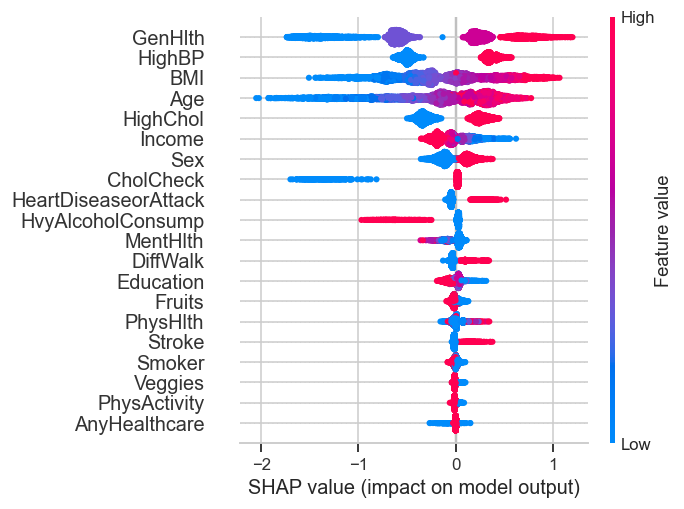

In [16]:
for name in ["shap_global_importance", "shap_beeswarm"]:
    png = reports / "figures" / f"{name}.png"
    if png.exists():
        display(Image(filename=str(png)))


### A single explained case

Signed contributions for one held-out patient. Positive pushes the model toward the
positive class, negative away from it. This is an explanation of **the model's output**,
not a clinical account of why this person is or is not ill.


In [17]:
local = shap_global["example_local_explanation"]
print("base value           :", round(local["base_value"], 4))
print("predicted probability:", round(local["predicted_probability"], 4))
display(pd.DataFrame(local["contributions"]))


base value           : 0.0062
predicted probability: 0.4626


,feature,value,contribution,description
0,GenHlth,2.0,-0.591541,Self-rated general health (1 excellent - 5 poor)
1,BMI,24.0,-0.532270,Body Mass Index
2,HighBP,1.0,0.429975,Ever told by a health professional you have hi...
3,Age,11.0,0.331502,13-level age category (1 = 18-24 ... 13 = 80+)
4,HighChol,1.0,0.234841,Ever told you have high cholesterol (0/1)
5,Income,4.0,0.189701,Income category (1 - 8 ordinal)
6,Sex,0.0,-0.133920,"Sex (0 = female, 1 = male)"
7,MentHlth,3.0,-0.059691,Days of poor mental health in past 30 days (0-30)
8,DiffWalk,0.0,-0.045860,Serious difficulty walking or climbing stairs ...
9,Education,5.0,0.039414,Education level (1 - 6 ordinal)


## 6. Model card

Intended use, out-of-scope use, and the limitations of this model.


In [18]:
display(Markdown((models / "MODEL_CARD.md").read_text(encoding="utf-8")))

# Model card — Diabetes Health-Indicator Risk Prediction

> **For research and educational purposes only. Predictions generated by this system are based on machine-learning models trained on historical public datasets and must not be interpreted as medical diagnosis or professional medical advice.**

_Created 2026-09-02._

## Intended use

Research and education: exploring how machine-learning models relate routinely collected clinical or survey variables to a recorded disease label, and how those relationships can be explained (SHAP). Suitable for teaching, methodology demonstrations and portfolio work.

### Out of scope

- Any clinical decision, diagnosis, triage, screening or treatment planning.
- Use on an individual patient to determine whether they have, or will develop, a disease.
- Deployment in a healthcare setting, or as a substitute for a qualified clinician.
- Populations, care settings or measurement protocols unlike the training cohort.

## Dataset

| field | value |
|---|---|
| `source` | UCI Machine Learning Repository |
| `uci_id` | 891 |
| `positive_class_meaning` | prediabetes or diabetes reported (BRFSS self-report) |
| `n_rows` | 253680 |
| `n_features` | 21 |
| `n_numeric` | 7 |
| `n_categorical` | 0 |
| `n_binary` | 14 |
| `target` | diabetes_or_prediabetes |
| `class_0` | 218334 |
| `class_1` | 35346 |
| `positive_rate` | 0.1393 |
| `total_missing_cells` | 0 |

## Model

| field | value |
|---|---|
| `algorithm` | xgboost |
| `calibration` | isotonic |
| `calibration_rationale` | Selected 'isotonic' by out-of-fold Brier score on the training set: 0.0966 vs raw 0.1747; cross-validated ROC-AUC 0.8304 vs raw 0.8303 (tolerance 0.01). The test set played no part in this choice. |
| `selection_rationale` | `xgboost` was chosen from 4 candidate pipelines. The cross-validated ranking (0.4·ROC-AUC + 0.4·PR-AUC + 0.2·recall) put `xgboost` first before tuning. After randomised hyper-parameter search the tuned cross-validated ROC-AUC scores were: xgboost 0.8304, lightgbm 0.8301, logreg 0.8221; `xgboost` was highest and was refit on the full training set. Accuracy was recorded but was not used as a selection criterion. |

> **The margin of selection is not meaningful.** `xgboost` beat `lightgbm` by 0.0003 cross-validated ROC-AUC, but the gap (0.0003) is smaller than the selected model's fold-to-fold standard deviation (0.0014); the gap (0.0003) is below 0.005, the practical resolution of ROC-AUC at this sample size. Treat the candidate models as performing comparably; a different random seed could easily reorder them. This choice should not be read as evidence that this algorithm is better suited to the problem.

**Candidates not evaluated (1).** The comparison below is over the remaining models only; nothing is claimed about how these would have performed.

- `svc` — Computationally intractable at this scale. SVC training is super-quadratic in the number of samples, and `probability=True` adds an internal 5-fold Platt calibration on top. Measured fit times on this training set were 1.07 s at n=2,000, 4.27 s at n=4,000, 17.52 s at n=8,000 and 85.09 s at n=16,000 — an empirical exponent of ~2.28, which extrapolates to roughly 7.7 hours for a single fit on the full 202,719 training rows and ~23 hours for one 5-fold cross-validation pass, before any hyper-parameter search. Excluded on cost, not on performance: it was never scored, so nothing is claimed about how it would have done.

Hyperparameters:

```json
{
  "clf__colsample_bytree": 0.7727780074568463,
  "clf__learning_rate": 0.02692655251486473,
  "clf__max_depth": 4,
  "clf__min_child_weight": 3,
  "clf__n_estimators": 766,
  "clf__reg_lambda": 8.906204386161678,
  "clf__subsample": 0.786705157299192
}
```

## Protocol

| field | value |
|---|---|
| `random_state` | 42 |
| `test_size` | 0.2000 |
| `cv_folds` | 5 |
| `split_strategy` | group_shuffle_holdout |
| `preprocessing` | Inside the model pipeline only: numeric = median imputation + standard scaling; categorical = most-frequent imputation + one-hot (handle_unknown='ignore'); binary = most-frequent imputation. Fitted on training folds only — never on the full dataset. |
| `selection_criteria` | Composite of cross-validated ROC-AUC (0.4), PR-AUC (0.4) and recall (0.2); accuracy is reported but not used to select. |

## Performance

_All figures below are measured on the held-out test set (or by cross-validation on the training set where stated). None are estimates._

### Cross-validation (training set)

| metric | value |
|---|---|
| `smote` | False |
| `roc_auc_mean` | 0.8301 |
| `roc_auc_std` | 0.0014 |
| `pr_auc_mean` | 0.4354 |
| `pr_auc_std` | 0.0077 |
| `recall_mean` | 0.7951 |
| `recall_std` | 0.0037 |
| `precision_mean` | 0.3065 |
| `precision_std` | 0.0049 |
| `f1_mean` | 0.4424 |
| `f1_std` | 0.0053 |
| `rank_score` | 0.6652 |

### Held-out test set (threshold 0.5)

| metric | value |
|---|---|
| `n` | 50961 |
| `prevalence` | 0.1383 |
| `threshold` | 0.5000 |
| `accuracy` | 0.8673 |
| `precision` | 0.5791 |
| `recall_sensitivity` | 0.1464 |
| `specificity` | 0.9829 |
| `f1` | 0.2338 |
| `roc_auc` | 0.8317 |
| `pr_auc` | 0.4307 |
| `brier` | 0.0959 |
| `cm_tn` | 43164 |
| `cm_fp` | 750 |
| `cm_fn` | 6015 |
| `cm_tp` | 1032 |

### Held-out test set (sensitivity-oriented threshold)

| metric | value |
|---|---|
| `n` | 50961 |
| `prevalence` | 0.1383 |
| `threshold` | 0.1388 |
| `accuracy` | 0.7213 |
| `precision` | 0.3056 |
| `recall_sensitivity` | 0.7984 |
| `specificity` | 0.7090 |
| `f1` | 0.4421 |
| `roc_auc` | 0.8317 |
| `pr_auc` | 0.4307 |
| `brier` | 0.0959 |
| `cm_tn` | 31133 |
| `cm_fp` | 12781 |
| `cm_fn` | 1421 |
| `cm_tp` | 5626 |
| `threshold_rule` | Youden's J (max sensitivity + specificity - 1) maximised on out-of-fold predictions over the TRAINING set, then applied unchanged to the test set. The test set played no part in choosing it. |

### Which threshold to read

> Positive-class prevalence is 0.1383. At threshold 0.5 the model recovers 0.1464 of positives at 0.9829 specificity; at the sensitivity-oriented threshold 0.1388 it recovers 0.7984 at 0.7090 specificity. The +0.6519 swing in recall means **0.5 is not a meaningful operating point for this model**. A calibrated probability on a problem with 13.8% prevalence only exceeds 0.5 for the most extreme profiles, so thresholding there behaves as a high-precision screen and misses most positives. The low recall in the 0.5 row is a property of that arbitrary cut-off, not evidence that the model failed to rank patients — ROC-AUC and PR-AUC, which are threshold-free, are the metrics to compare against other models. Any real use would set the threshold from the cost of a false negative against a false alarm.

### Calibration comparison

| method | brier | roc_auc |
|---|---|---|
| raw | 0.1736 | 0.8319 |
| sigmoid | 0.0962 | 0.8318 |
| isotonic | 0.0959 | 0.8317 |

### What actually drives this score

> No values are missing in this dataset, so measurement pattern cannot carry signal.

### The ceiling imposed by the feature set

> 38,000 of 253,680 rows (14.98%) share an identical feature vector with at least one other row, and 1,566 of those groups contain both outcome labels. 1,640 rows are therefore unwinnable for any model using only these features, capping accuracy at 0.9935 against the measured 0.8673. The bound is 0.1262 above what the model achieves, so it does NOT explain the shortfall — duplicate-label conflict is a real but minor part of the error here, and the rest is the model, the features' weak association with the outcome, or both.

Detail: 227,908 distinct feature vectors describe 253,680 rows. 1,566 groups of identical rows disagree about the outcome, covering 5,218 rows. Assuming the best possible prediction for every such group (its majority label), 1,640 rows must still be wrong — a hard upper bound of 0.9935 accuracy for **any** model restricted to these features. This bound is a property of the data, not of the model: it says where perfect accuracy stops being available, and the note above says whether it accounts for this model's actual error.

### Imbalance strategy: SMOTE vs class weighting

> SMOTE vs class weighting, same model and same folds: PR-AUC 0.4243 vs 0.4354 (-0.0111, fold std 0.0082) — a degradation. ROC-AUC moved -0.0061 and recall at threshold 0.5 moved -0.5053; recall moves most because both strategies shift the operating point rather than the ranking. Shipped strategy: class_weight.

| strategy | roc_auc_mean | pr_auc_mean | recall_mean | precision_mean | f1_mean | fit_seconds_mean |
|---|---|---|---|---|---|---|
| class_weight | 0.8301 | 0.4354 | 0.7951 | 0.3065 | 0.4424 | 32.0226 |
| smote | 0.8239 | 0.4243 | 0.2899 | 0.5012 | 0.3673 | 65.8828 |

## Explainability

Method: SHAP, aggregated from the transformed columns back to original features

| rank | feature | mean_abs_shap | mean_shap | description |
|---|---|---|---|---|
| 1 | GenHlth | 0.6534 | -0.2752 | Self-rated general health (1 excellent - 5 poor) |
| 2 | HighBP | 0.4437 | -0.1209 | Ever told by a health professional you have high blood pressure (0/1) |
| 3 | BMI | 0.4147 | -0.1275 | Body Mass Index |
| 4 | Age | 0.4042 | -0.1341 | 13-level age category (1 = 18-24 ... 13 = 80+) |
| 5 | HighChol | 0.2981 | -0.0704 | Ever told you have high cholesterol (0/1) |
| 6 | Income | 0.1397 | -0.0413 | Income category (1 - 8 ordinal) |
| 7 | Sex | 0.1348 | -0.0140 | Sex (0 = female, 1 = male) |
| 8 | CholCheck | 0.0715 | -0.0288 | Cholesterol check within the past 5 years (0/1) |
| 9 | HeartDiseaseorAttack | 0.0674 | -0.0201 | Coronary heart disease or myocardial infarction (0/1) |
| 10 | HvyAlcoholConsump | 0.0652 | -0.0154 | Heavy alcohol consumption (0/1) |

## Limitations

- Features are self-reported survey answers (CDC BRFSS 2015), not laboratory measurements. The target is a self-reported diagnosis of prediabetes or diabetes, so people with undiagnosed diabetes are labelled negative — the model learns who has *been told* they have diabetes, which tracks access to healthcare as well as disease.
- This estimates a RISK ASSOCIATION with reported diabetes status, not a diagnosis and not a future-onset prediction — the data is cross-sectional, so no temporal ordering between features and outcome is established. A high score means 'resembles respondents who reported diabetes', never 'will develop diabetes'.
- Survey weighting is not applied, so the sample is not nationally representative and the ~14% positive rate is a property of this release, not of any population.
- 38,000 of 253,680 rows (15.0%) share an identical feature vector with at least one other row, because 21 mostly-binary survey answers cannot distinguish 253,680 people. The train/test split is grouped on the feature vector so identical profiles never straddle the split; without that, the test set would contain rows the model had already seen.
- Several features are plausibly consequences of diabetes rather than causes of it (general health rating, difficulty walking, heart disease history). SHAP attributions describe the model's use of these variables and must not be read as causal or as intervention targets.
- Discrimination is moderate (ROC-AUC ~0.83), which is what self-reported indicators support. Treat the probability as a coarse ordering of survey respondents, not a per-person risk estimate.

## Risk bands

_Illustrative presentation buckets for a model-estimated probability. Not clinical decision thresholds; they carry no medical meaning._

| label | min | max |
|---|---|---|
| low | 0.00 | 0.33 |
| moderate | 0.33 | 0.66 |
| high | 0.66 | 1.01 |

---
*Generated by `ml.model_card.write_model_card`.*
